In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Colab/tested.csv')

print(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumns:")
print(df.columns)

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name     Sex   Age  SibSp  Parch  \
0                              Kelly, Mr. James    male  34.5      0      0   
1              Wilkes, Mrs. James (Ellen Needs)  female  47.0      1      0   
2                     Myles, Mr. Thomas Francis    male  62.0      0      0   
3                              Wirz, Mr. Albert    male  27.0      0      0   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female  22.0      1      1   

    Ticket     Fare Cabin Embarked  
0   330911   7.8292   NaN        Q  
1   363272   7.0000   NaN        S  
2   240276   9.6875   NaN        Q  
3   315154   8.6625   NaN        S  
4  3101298  12.2875   NaN        S  

Dataset Shape: (418, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name'

In [4]:
df = pd.get_dummies(
    df,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

print(df.head())

   PassengerId  Survived  Pclass  \
0          892         0       3   
1          893         1       3   
2          894         0       2   
3          895         0       3   
4          896         1       3   

                                           Name   Age  SibSp  Parch   Ticket  \
0                              Kelly, Mr. James  34.5      0      0   330911   
1              Wilkes, Mrs. James (Ellen Needs)  47.0      1      0   363272   
2                     Myles, Mr. Thomas Francis  62.0      0      0   240276   
3                              Wirz, Mr. Albert  27.0      0      0   315154   
4  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  22.0      1      1  3101298   

      Fare Cabin  Sex_male  Embarked_Q  Embarked_S  
0   7.8292   NaN      True        True       False  
1   7.0000   NaN     False       False        True  
2   9.6875   NaN      True        True       False  
3   8.6625   NaN      True       False        True  
4  12.2875   NaN     False       Fals

/tmp/ipykernel_3803/1516757049.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)



Features:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Sex_male', 'Embarked_Q', 'Embarked_S']

Target:
Fare

Training data shape:
(334, 8)

Testing data shape:
(84, 8)

Feature scaling completed.

Linear Regression model trained successfully.

LINEAR REGRESSION RESULTS
Mean Squared Error (MSE): 1433.3304
Root Mean Squared Error (RMSE): 37.8594
R2 Score: 0.3259

Actual vs Predicted:
   Actual Fare  Predicted Fare
0       7.2292       13.764289
1     211.3375       75.803745
2       7.7500       -5.340391
3       7.8958       -2.036069
4      12.1833       31.729436
5      26.0000       45.817356
6       7.9250        4.628623
7      26.0000       71.106771
8      13.0000       32.837239
9       8.0500       -4.361622


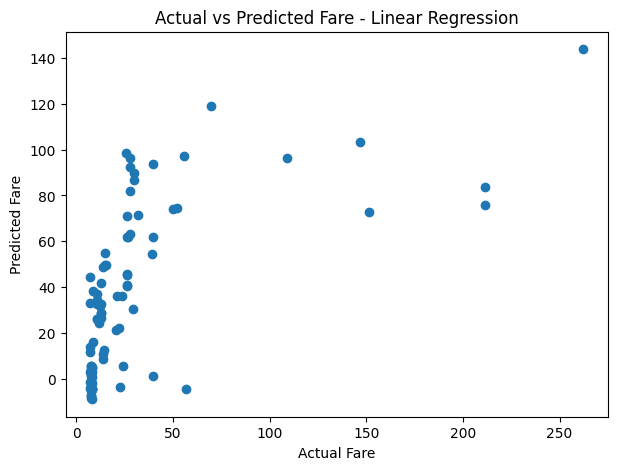

In [11]:


# ============================================================
# 5. DEFINE FEATURES AND TARGET
# ============================================================

# Handle missing values in 'Age' by filling with the mean
df['Age'].fillna(df['Age'].mean(), inplace=True)

# Handle missing values in 'Fare' by filling with the mean
df['Fare'].fillna(df['Fare'].mean(), inplace=True)

# Predict Fare using the remaining Titanic attributes

X = df.drop(columns=['Fare', 'Name', 'Ticket', 'Cabin', 'PassengerId'])
y = df['Fare']

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Fare")


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining data shape:")
print(X_train.shape)

print("\nTesting data shape:")
print(X_test.shape)


# ============================================================
# 7. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed.")


# ============================================================
# 8. LINEAR REGRESSION MODEL
# ============================================================

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("\nLinear Regression model trained successfully.")


# ============================================================
# 9. PREDICTION
# ============================================================

y_pred = linear_model.predict(
    X_test_scaled
)


# ============================================================
# 10. MODEL EVALUATION
# ============================================================

mse = mean_squared_error(
    y_test,
    y_pred
)

rmse = np.sqrt(mse)

r2 = r2_score(
    y_test,
    y_pred
)

print("\n============================================")
print("LINEAR REGRESSION RESULTS")
print("============================================")

print("Mean Squared Error (MSE):", round(mse, 4))

print("Root Mean Squared Error (RMSE):", round(rmse, 4))

print("R2 Score:", round(r2, 4))


# ============================================================
# 11. ACTUAL VS PREDICTED VALUES
# ============================================================

comparison = pd.DataFrame({
    'Actual Fare': y_test.values,
    'Predicted Fare': y_pred
})

print("\nActual vs Predicted:")
print(comparison.head(10))


# ============================================================
# 12. ACTUAL VS PREDICTED PLOT
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")

plt.title(
    "Actual vs Predicted Fare - Linear Regression"
)

plt.show()